In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
checking_df = df.sample(10000)

In [5]:
df.shape

(50000, 2)

In [6]:
df['review'][2]

'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I\'d laughed at one of Woody\'s comedies in years (dare I say a decade?). While I\'ve never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.'

In [7]:
df['review'].str.lower()

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. <br /><br />the...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot, bad dialogue, bad acting, idiotic di...
49997    i am a catholic taught in parochial elementary...
49998    i'm going to have to disagree with the previou...
49999    no one expects the star trek movies to be high...
Name: review, Length: 50000, dtype: object

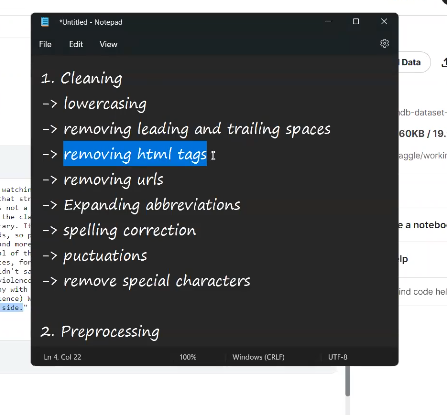

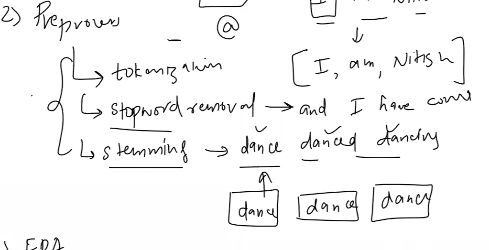

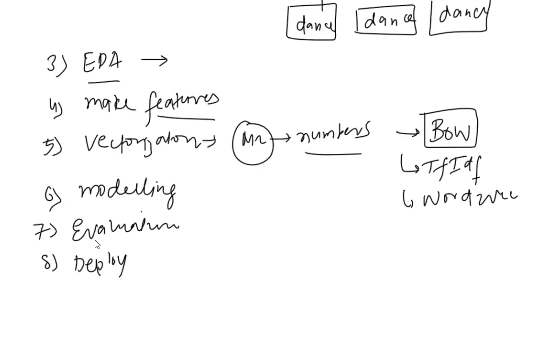

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
df.duplicated().sum()

418

In [10]:
df = df.drop_duplicates()

In [11]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [12]:
df.sample(10000)

,review,sentiment
48810,Just watched this on DVD three times - Once th...,positive
42746,Homecoming; what a HUGE disappointment!! After...,negative
6072,"For those curious, this episode is based in th...",positive
28927,Circus could have been so much better if they ...,negative
44746,I remember running home from school almost eve...,positive
...,...,...
47239,This is the first feature film from Australian...,positive
11577,The third collaboration for Karloff and Lugosi...,positive
24029,There is no denying that Ealing comedies are g...,positive
44090,Today You Die was the 4th Seagal movie in a mi...,negative


In [13]:
df = df.iloc[:10000]

In [14]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
10012,I was pleasantly surprised to find that How to...,positive
10013,This is a very moving film that takes a new tw...,positive
10014,Apart from the beautiful imagery thanks to New...,negative
10015,This is a perfect series for family viewing. W...,positive


In [15]:
#cleanning

#lower_case

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [16]:
df['review'] = df['review'].str.lower()

/tmp/ipykernel_37/724319867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].str.lower()


In [17]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [18]:
# remove white spaces

df['review'] = df['review'].str.strip()

/tmp/ipykernel_37/1856068925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].str.strip()


In [19]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [20]:
#removing HTML tags
#regular expression

import re
def remove_html(data):
    data = re.sub(r'<[^>]+>', '', data)
    return data

In [21]:
df['review'] = df['review'].apply(remove_html)

/tmp/ipykernel_37/2166420511.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_html)


In [22]:
# df['review'] = df['review'].str.replace(r'<[^>]+>', '')

In [23]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [24]:
#removing URLs
#as urls dont contributes to the semantic meanings

In [25]:
def remove_url(data):
    data = re.sub(r'http\S+|www\S+', '',data)
    return data

In [26]:
df['review'].apply(remove_url)

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
10012    i was pleasantly surprised to find that how to...
10013    this is a very moving film that takes a new tw...
10014    apart from the beautiful imagery thanks to new...
10015    this is a perfect series for family viewing. w...
10016    a really very bad movie, with a very few good ...
Name: review, Length: 10000, dtype: object

In [27]:
# this is for vectorized string operations
df['review'].str.replace(r'http\S+|www\S+', '')

0        one of the other reviewers has mentioned that ...
1        a wonderful little production. the filming tec...
2        i thought this was a wonderful way to spend ti...
3        basically there's a family where a little boy ...
4        petter mattei's "love in the time of money" is...
                               ...                        
10012    i was pleasantly surprised to find that how to...
10013    this is a very moving film that takes a new tw...
10014    apart from the beautiful imagery thanks to new...
10015    this is a perfect series for family viewing. w...
10016    a really very bad movie, with a very few good ...
Name: review, Length: 10000, dtype: object

In [28]:
df[df['review'].str.contains(r'http\S+|www\S+', '')]['review'].iloc[0]

'first of all, let\'s get a few things straight here: a) i am an anime fan- always has been as a matter of fact (i used to watch speed racer all the time in preschool). b) i do like several b-movies because they\'re hilarious. c) i like the godzilla movies- a lot.moving on, when the movie first comes on, it seems like it\'s going to be your usual b-movie, down to the crappy fx, but all a sudden- boom! the anime comes on! this is when the movie goes wwwaaaaayyyyy downhill.the animation is very bad & cheap, even worse than what i remember from speed racer, for crissakes! in fact, it\'s so cheap, one of the few scenes from the movie i "vividly" remember is when a bunch of kids run out of a school... & it\'s the same kids over & over again! the fx are terrible, too; the dinosaurs look worse than godzilla. in addition, the transition to live action to animation is unorganized, the dialogue & voices(especially the english dub that i viewed) was horrid & i was begging my dad to take the tape 

In [29]:
# very good srategy to check that , is it even there or not(contains)
df[df['review'].str.contains(r'http\S+|www\S+', '')].shape

(38, 2)

In [30]:
df['review'] = df['review'].str.replace(r'http\S+|www\S+', '')

/tmp/ipykernel_37/2748103816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].str.replace(r'http\S+|www\S+', '')


In [31]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [32]:
#expanding abbv..

import re

def expand_abb(data):
    contractions = {
        r"\bhe's\b": "he is",
        r"\bthere's\b": "there is",
        r"\bwe're\b": "we are",
        r"\bwon't\b": "will not",
        r"\bthey're\b": "they are",
        r"\bcan't\b": "cannot",
        r"\bwasn't\b": "was not",
        r"\bdon't\b": "do not",
        r"\baren't\b": "are not",
        r"\bisn't\b": "is not",
        r"\bwhat's\b": "what is",
        r"\bhasn't\b": "has not",
        r"\bhe's\b": "he is",
        r"\byou're\b": "you are",
        r"\bit's\b": "it is",
        r"\bi'm\b": "i am",
        r"\bdidn't\b": "did not",
        r"\bshouldn't\b": "should not",
        r"\bwouldn't\b": "would not",
        r"\bcouldn't\b": "could not",
        r"\bdoesn't\b": "does not"
    }

    for pattern, repl in contractions.items():
        data = re.sub(pattern, repl, data, flags=re.IGNORECASE)

    return data


In [33]:
expand_abb("we're")

'we are'

In [34]:
df['review'] = df['review'].apply(expand_abb)

/tmp/ipykernel_37/3408431772.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(expand_abb)


In [35]:
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there is a family where a little boy...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [36]:
#spelling correction 
#it is pretty tough here so we have to use extarlan libraries
#TextBlob

In [37]:
from textblob import TextBlob

text = "hi i can drivve at nigt"
TextBlob(text).correct().string

'hi i can drive at night'

In [38]:
def spelling_corr(data):
    return TextBlob(data).correct().string

In [39]:
# df['review'].apply(spelling_corr)  
#not running it as it taking a huge time

In [40]:
# remove punctuation

import string

In [41]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
# def remove_punc(data):
#     data = re.sub('!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~','',data)
#     return data
                  
                  

In [43]:
# df[df['review'].str.contains(r'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~')]

In [44]:
def remove_punc(data):
    for i in string.punctuation:
        if i in data:
            data = data.replace(i,'')
    return data        

In [45]:
remove_punc('hi how are you?')

'hi how are you'

In [46]:
df['review'] = df['review'].apply(remove_punc)

/tmp/ipykernel_37/1430356720.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['review'].apply(remove_punc)


In [47]:
df['review'].head()

0    one of the other reviewers has mentioned that ...
1    a wonderful little production the filming tech...
2    i thought this was a wonderful way to spend ti...
3    basically there is a family where a little boy...
4    petter matteis love in the time of money is a ...
Name: review, dtype: object

In [48]:
#remove special characters
# all the special char are already there in punctions

In [49]:
#this is the basic boilerplate of NLP data cleanning

**Preprocessing**

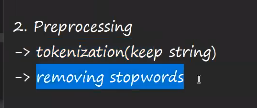

In [50]:
#Tokenization-> word

from nltk.tokenize import word_tokenize 

In [51]:
df['tokenized_review'] = df['review'].apply(word_tokenize)

/tmp/ipykernel_37/978643584.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokenized_review'] = df['review'].apply(word_tokenize)


In [52]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."


In [53]:
#stopwords removal
from nltk.corpus import stopwords

In [54]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [55]:
def remove_stopwords(data):
    L = []
    for i in data:
        if i not in stopwords.words('english'):
            L.append(i)
    return L        

In [56]:
remove_stopwords(['i', 'thought', 'this', 'was', 'a', 'wonderful'])

['thought', 'wonderful']

In [57]:
df['tokenized_review'] = df['tokenized_review'].apply(remove_stopwords)

/tmp/ipykernel_37/3444714658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokenized_review'] = df['tokenized_review'].apply(remove_stopwords)


In [58]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,..."


In [59]:
df['review'] = df['tokenized_review'].apply(lambda x:" ".join(x))

/tmp/ipykernel_37/1304386799.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review'] = df['tokenized_review'].apply(lambda x:" ".join(x))


In [60]:
df.head()

,review,sentiment,tokenized_review
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn..."
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,..."


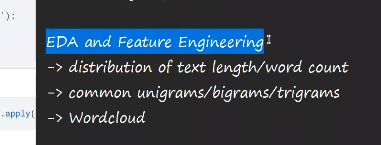

***EDA***

In [61]:
#Feature engineering

df['tokenized_review'].apply(lambda x:len(x))

0        167
1         84
2         86
3         64
4        125
        ... 
10012     84
10013     60
10014    155
10015    149
10016    320
Name: tokenized_review, Length: 10000, dtype: int64

In [62]:
df['char_length'] = df['review'].str.len()

/tmp/ipykernel_37/3571495401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['char_length'] = df['review'].str.len()


In [63]:
df.head()

,review,sentiment,tokenized_review,char_length
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1148
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",656
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",589
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,...",440
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",863


In [64]:
df['word_length'] = df['tokenized_review'].apply(lambda x:len(x))

/tmp/ipykernel_37/3044716156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_length'] = df['tokenized_review'].apply(lambda x:len(x))


In [65]:
df.head()

,review,sentiment,tokenized_review,char_length,word_length
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1148,167
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",656,84
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",589,86
3,basically family little boy jake thinks zombie...,negative,"[basically, family, little, boy, jake, thinks,...",440,64
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",863,125


In [66]:
temp = df.groupby('sentiment')['char_length'].mean().reset_index()

<BarContainer object of 2 artists>

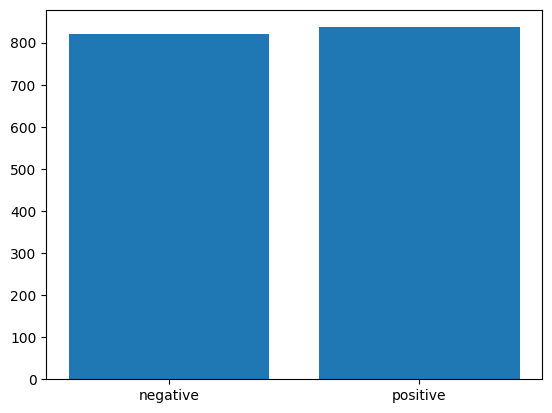

In [67]:
import matplotlib.pyplot as plt
plt.bar(temp['sentiment'],temp['char_length'])

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: xlabel='char_length', ylabel='Count'>

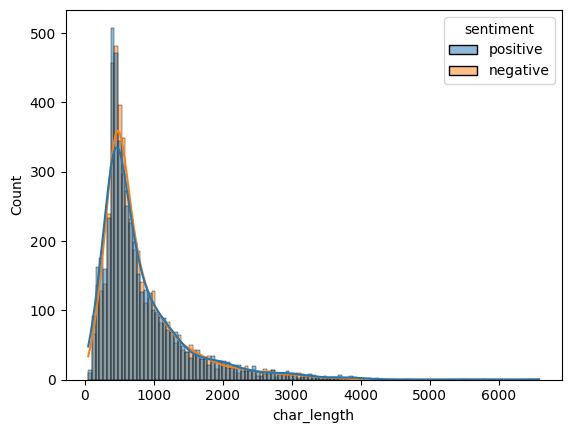

In [68]:
import seaborn as sns
sns.histplot(data=df, x='char_length', hue='sentiment', kde=True)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


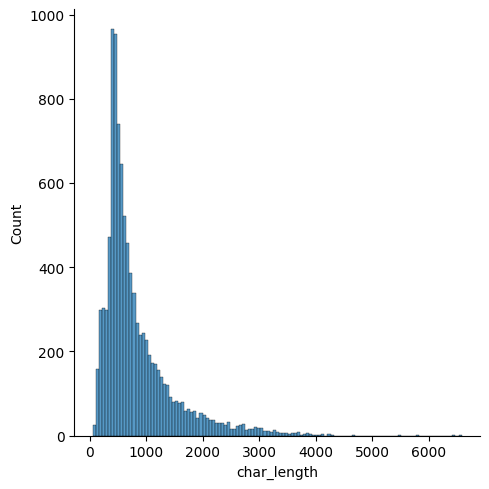

In [69]:
sns.displot(df['char_length'])

In [70]:
temp_pos = df[df['sentiment'] == 'positive']

In [71]:
temp_pos.head()

,review,sentiment,tokenized_review,char_length,word_length
0,one reviewers mentioned watching 1 oz episode ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1148,167
1,wonderful little production filming technique ...,positive,"[wonderful, little, production, filming, techn...",656,84
2,thought wonderful way spend time hot summer we...,positive,"[thought, wonderful, way, spend, time, hot, su...",589,86
4,petter matteis love time money visually stunni...,positive,"[petter, matteis, love, time, money, visually,...",863,125
5,probably alltime favorite movie story selfless...,positive,"[probably, alltime, favorite, movie, story, se...",394,57


/tmp/ipykernel_37/3643744555.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(temp_pos['char_length'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='char_length', ylabel='Density'>

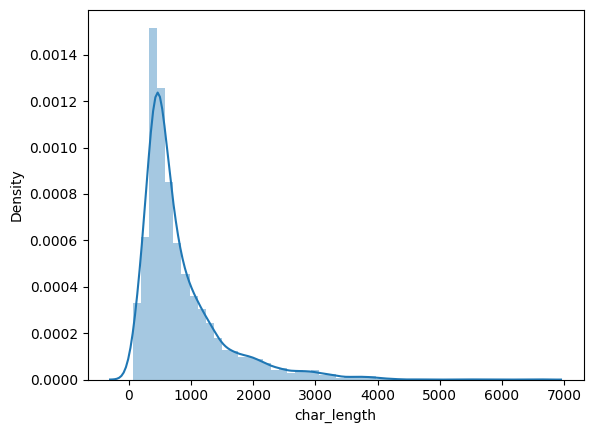

In [72]:
sns.distplot(temp_pos['char_length'])

In [73]:
temp_neg = df[df['sentiment'] == 'negative']

/tmp/ipykernel_37/444331389.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(temp_neg['char_length'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


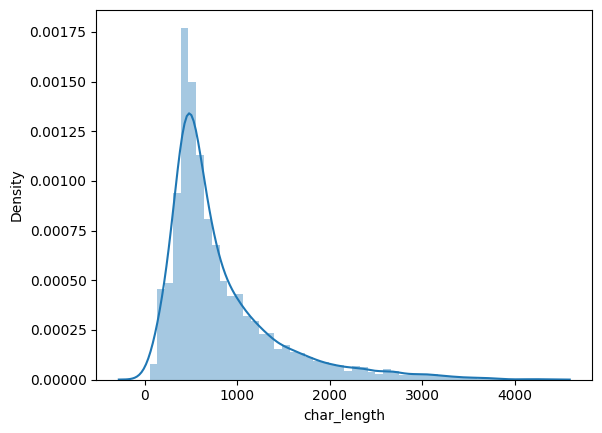

In [74]:
sns.distplot(temp_neg['char_length'])
plt.show()

/tmp/ipykernel_37/544523946.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(temp_pos['char_length'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_37/544523946.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).



<Axes: xlabel='char_length', ylabel='Density'>

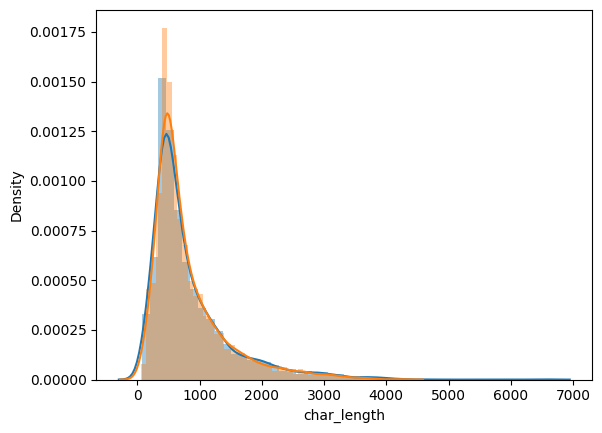

In [75]:
sns.distplot(temp_pos['char_length'])
sns.distplot(temp_neg['char_length'])


/tmp/ipykernel_37/3590494347.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['sentiment'] == 'positive']['word_length'])
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/tmp/ipykernel_37/3590494347.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level 

<Axes: xlabel='word_length', ylabel='Density'>

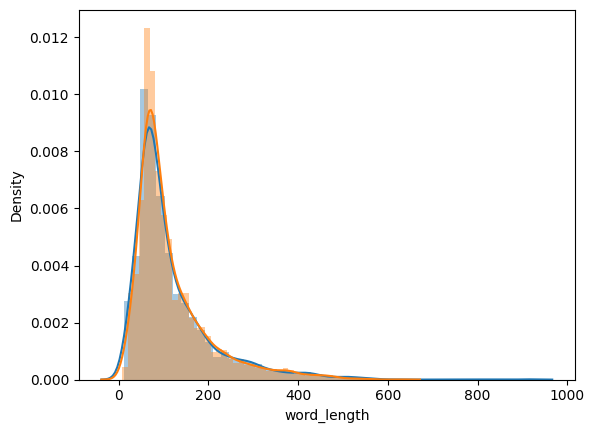

In [76]:
sns.distplot(df[df['sentiment'] == 'positive']['word_length'])
sns.distplot(df[df['sentiment'] == 'negative']['word_length'])


In [77]:
#another way to get the no of stopwords here

In [78]:
#unigrams , bigrams, trigrams #ngrams

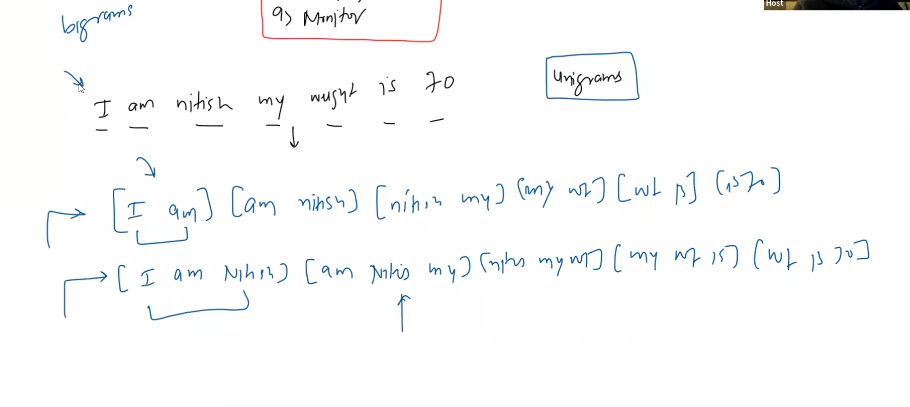

In [79]:
df['tokenized_review'].sum()

['one',
 'reviewers',
 'mentioned',
 'watching',
 '1',
 'oz',
 'episode',
 'youll',
 'hooked',
 'right',
 'exactly',
 'happened',
 'methe',
 'first',
 'thing',
 'struck',
 'oz',
 'brutality',
 'unflinching',
 'scenes',
 'violence',
 'set',
 'right',
 'word',
 'go',
 'trust',
 'show',
 'faint',
 'hearted',
 'timid',
 'show',
 'pulls',
 'punches',
 'regards',
 'drugs',
 'sex',
 'violence',
 'hardcore',
 'classic',
 'use',
 'wordit',
 'called',
 'oz',
 'nickname',
 'given',
 'oswald',
 'maximum',
 'security',
 'state',
 'penitentary',
 'focuses',
 'mainly',
 'emerald',
 'city',
 'experimental',
 'section',
 'prison',
 'cells',
 'glass',
 'fronts',
 'face',
 'inwards',
 'privacy',
 'high',
 'agenda',
 'em',
 'city',
 'home',
 'manyaryans',
 'muslims',
 'gangstas',
 'latinos',
 'christians',
 'italians',
 'irish',
 'moreso',
 'scuffles',
 'death',
 'stares',
 'dodgy',
 'dealings',
 'shady',
 'agreements',
 'never',
 'far',
 'awayi',
 'would',
 'say',
 'main',
 'appeal',
 'show',
 'due',
 'f

In [80]:
from nltk import ngrams
pd.Series(ngrams(df['tokenized_review'].sum(),2)).value_counts()

(ever, seen)                459
(special, effects)          438
(ive, seen)                 430
(even, though)              372
(one, best)                 348
                           ... 
(dead, make)                  1
(unexpected, appearance)      1
(really, liven)               1
(liven, party)                1
(hurt, yet)                   1
Name: count, Length: 848015, dtype: int64

In [ ]:
# pd.Series(ngrams(df['tokenized_review'].sum(),3)).value_counts()

In [ ]:
#wordcloud

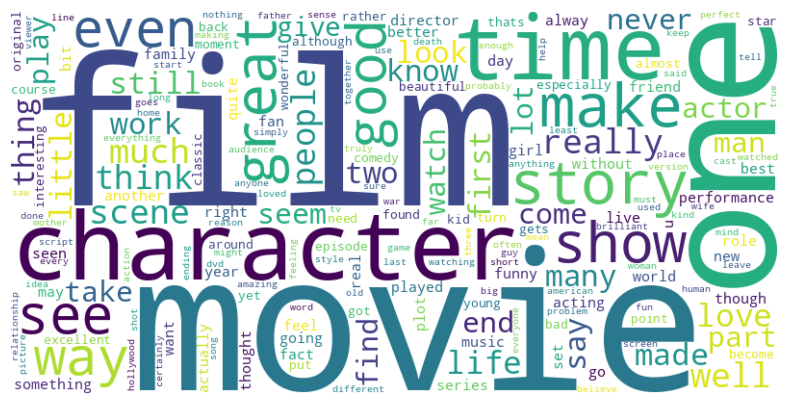

In [83]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text from your reviews into one string
text = " ".join(df[df['sentiment']=='positive']['review'])

# Create and configure the wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',   # you can try 'plasma', 'cool', 'inferno', etc.
    max_words=200,
    stopwords=None
).generate(text)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


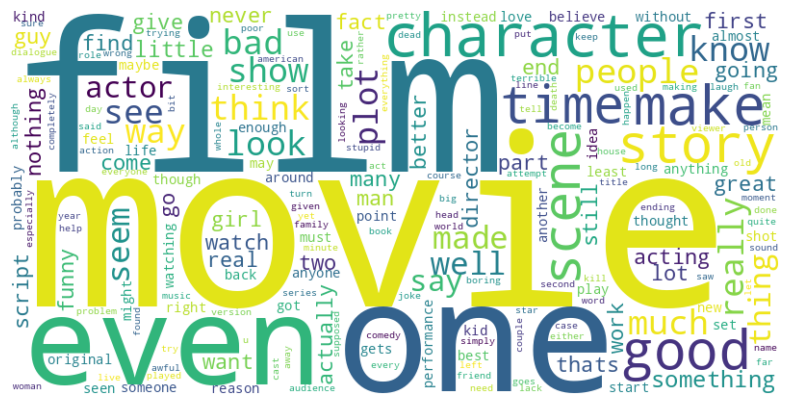

In [84]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all text from your reviews into one string
text = " ".join(df[df['sentiment']=='negative']['review'])

# Create and configure the wordcloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',   # you can try 'plasma', 'cool', 'inferno', etc.
    max_words=200,
    stopwords=None
).generate(text)

# Display the wordcloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [85]:
pd.Series(ngrams(df[df['sentiment']=='positive']['tokenized_review'].sum(),1)).value_counts()

(film,)         7644
(movie,)        7308
(one,)          5120
(like,)         3376
(good,)         2840
                ... 
(rages,)           1
(sawing,)          1
(itwatch,)         1
(nicoletis,)       1
(friar,)           1
Name: count, Length: 55085, dtype: int64

In [86]:
pd.Series(ngrams(df[df['sentiment']=='negative']['tokenized_review'].sum(),1)).value_counts()

(movie,)           9521
(film,)            6933
(one,)             4831
(like,)            4446
(would,)           3119
                   ... 
(bombshelter,)        1
(blathering,)         1
(stomachscott,)       1
(turkeythe,)          1
(renumber,)           1
Name: count, Length: 53253, dtype: int64

In [89]:
#vectorization 
#BoW-> bag of words

In [90]:
#BoW
# Bag of Words (BoW)

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Initialize the CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000)

# Fit and transform the text data
bag_of_words = count_vectorizer.fit_transform(df['review'])

# Convert to a DataFrame
bag_of_words = pd.DataFrame(
    bag_of_words.toarray(),
    columns=count_vectorizer.get_feature_names_out()
)

# Display the resulting DataFrame
bag_of_words.head()


,10,100,1000,1010,11,110,12,13,13th,14,...,youd,youll,young,younger,youth,youve,zero,zombie,zombies,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [91]:
bag_of_words

,10,100,1000,1010,11,110,12,13,13th,14,...,youd,youll,young,younger,youth,youve,zero,zombie,zombies,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9998,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [92]:
# We worked here as a Data analyst

In [94]:
# PCA on Bag of Words
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 3 components (for 3D visualization)
pca = PCA(n_components=2)

# Fit and transform the BoW data
pca_result = pca.fit_transform(bag_of_words.values)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# Display the first few rows
pca_df.head()


,PC1,PC2
0,-1.310656,-0.490399
1,-2.185536,-0.576077
2,-1.965658,-0.470286
3,-0.469468,0.751618
4,1.641293,-1.124568


In [95]:
pca_df

,PC1,PC2
0,-1.310656,-0.490399
1,-2.185536,-0.576077
2,-1.965658,-0.470286
3,-0.469468,0.751618
4,1.641293,-1.124568
...,...,...
9995,-1.971841,-1.040512
9996,-1.289247,-1.228197
9997,1.009451,-2.735129
9998,-0.896834,0.246089


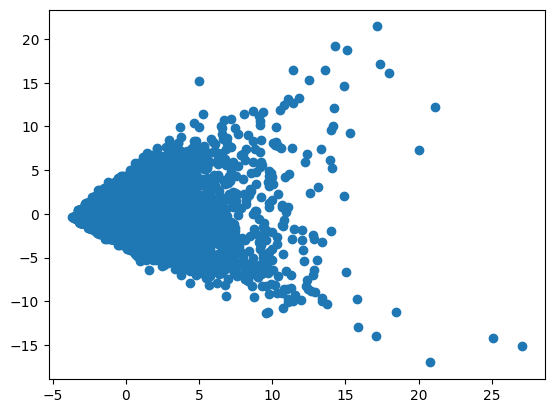

In [96]:
plt.scatter(pca_df['PC1'],pca_df['PC2'])

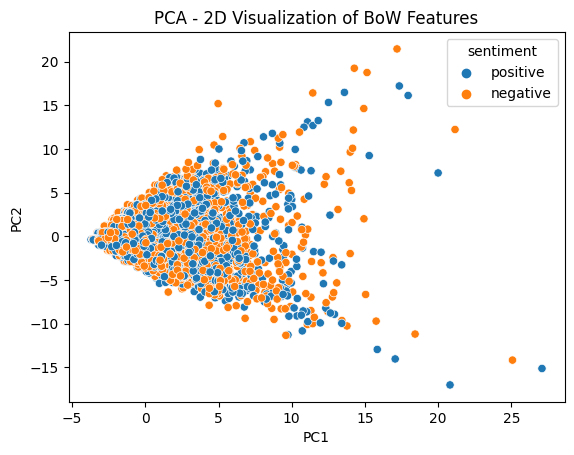

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue=df['sentiment'])
plt.title('PCA - 2D Visualization of BoW Features')
plt.show()
